In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import PartialDependenceDisplay

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")


In [50]:
df = pd.read_csv("station_summary_model_encoded.csv")
print("Raw shape:", df.shape)
df.head()


Raw shape: (242417, 26)


,id,latitude,longitude,ports,power_kw,is_fast_dc,total_power_kw,total_evs,avg_battery,SUV,...,Van_pct,mostly_fast_dc,high_ev_count,power_class_AC_L1_(<7.5kW),power_class_AC_L2_(7.5-21kW),power_class_DC_FAST_(50-149kW),power_class_DC_ULTRA_(>=150kW),power_class_UNKNOWN,power_tier_Level 2,power_tier_Ultra DC
0,2389,34.040539,-118.271387,1,3.7,False,3.7,11,88.181818,6,...,0.0,False,True,True,False,False,False,False,True,False
1,2391,34.059133,-118.248589,1,50.0,True,50.0,11,88.181818,6,...,0.0,True,True,False,False,True,False,False,False,False
2,2396,38.576769,-121.495022,1,3.7,False,3.7,11,88.181818,6,...,0.0,False,True,True,False,False,False,False,True,False
3,2399,38.438052,-122.711357,1,NaN,False,NaN,11,88.181818,6,...,0.0,False,True,False,False,False,False,True,True,False
4,2441,34.145138,-118.152655,1,3.7,False,3.7,11,88.181818,6,...,0.0,False,True,True,False,False,False,False,True,False


In [51]:
#Building Charging Time Varible
df["power_kw"] = pd.to_numeric(df["power_kw"], errors="coerce")
df["avg_battery"] = pd.to_numeric(df["avg_battery"], errors="coerce")

# invalid power
df.loc[df["power_kw"] <= 0, "power_kw"] = np.nan

df["charge_time_est_mins"] = (df["avg_battery"] / df["power_kw"]) * 60

print("Missing charging time before drop:", df["charge_time_est_mins"].isna().sum())
df = df.dropna(subset=["charge_time_est_mins"]).reset_index(drop=True)
print("After drop:", df.shape)

# remove extreme outliers (1%–99%)
Q1 = df["charge_time_est_mins"].quantile(0.01)
Q3 = df["charge_time_est_mins"].quantile(0.99)
df = df[(df["charge_time_est_mins"] >= Q1) & (df["charge_time_est_mins"] <= Q3)].reset_index(drop=True)
print("After outlier removal:", df.shape)
df[["avg_battery", "power_kw", "charge_time_est_mins"]].describe()



Missing charging time before drop: 4690
After drop: (237727, 27)
After outlier removal: (234407, 27)


,avg_battery,power_kw,charge_time_est_mins
count,234407.000000,234407.000000,234407.000000
mean,79.537890,29.145353,666.666555
std,6.262990,49.961425,576.769947
min,75.000000,2.700000,15.000000
25%,75.000000,3.700000,204.545455
50%,75.000000,11.000000,409.090909
75%,88.181818,22.000000,1429.975430
max,88.181818,351.000000,1763.636364


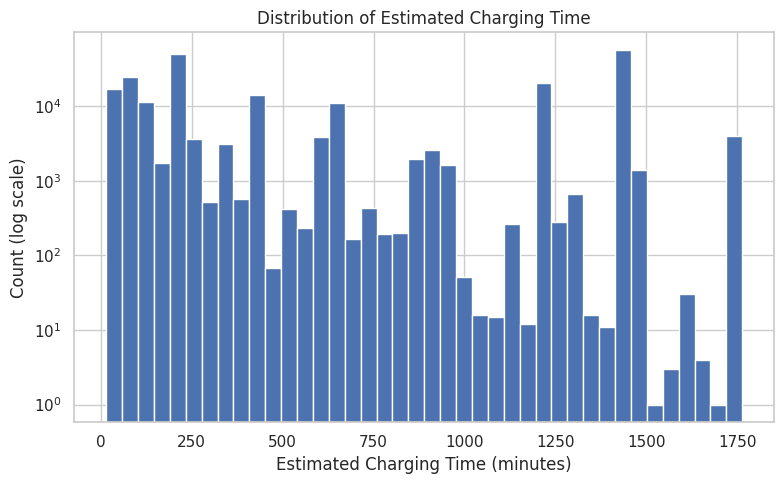

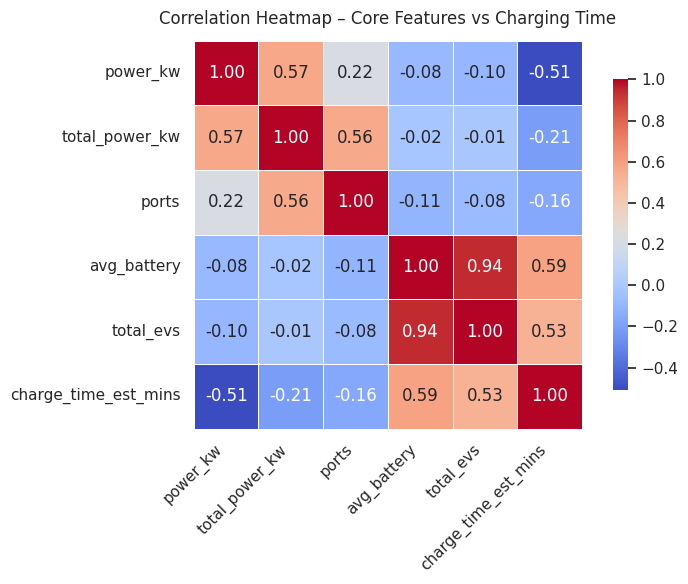

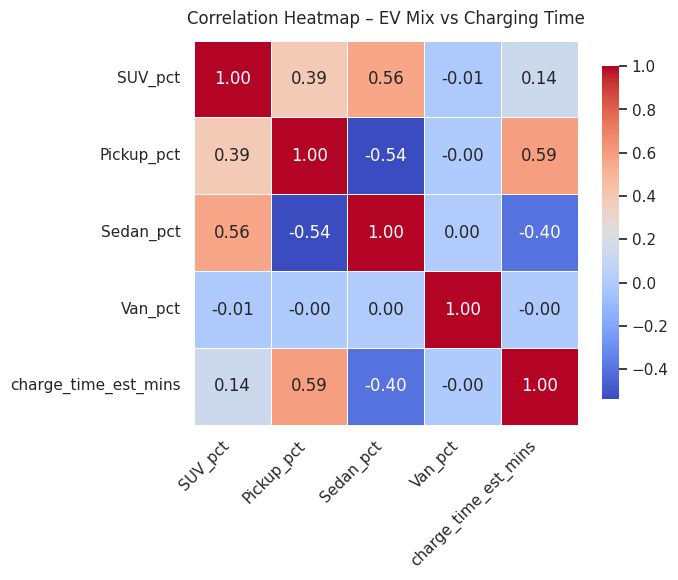

In [52]:
# Histogram of charging time
plt.figure(figsize=(8,5))
plt.hist(df["charge_time_est_mins"], bins=40)
plt.yscale("log")
plt.xlabel("Estimated Charging Time (minutes)")
plt.ylabel("Count (log scale)")
plt.title("Distribution of Estimated Charging Time")
plt.tight_layout()
plt.show()

# Features we will use
features = [
    "power_kw",
    "total_power_kw",
    "ports",
    "avg_battery",
    "total_evs"
]
target = "charge_time_est_mins"

sns.set(style="white")
core_features = features + [target]

corr1 = df[core_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr1,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Heatmap – Core Features vs Charging Time", pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

ev_mix_features = ["SUV_pct", "Pickup_pct", "Sedan_pct", "Van_pct"]

corr2 = df[ev_mix_features + ["charge_time_est_mins"]].corr()

plt.figure(figsize=(7,6))
sns.heatmap(
    corr2,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Heatmap – EV Mix vs Charging Time", pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [53]:
#Feature Matrix for X and Y
X = df[features]
y = df[target]

# one-hot encode any categoricals (none here, but safe)
X_encoded = pd.get_dummies(X, drop_first=True)

# ensure numeric & impute
X_encoded = X_encoded.apply(pd.to_numeric, errors="coerce")
X_encoded = X_encoded.fillna(X_encoded.median())

print("X_encoded shape:", X_encoded.shape)
X_encoded.head()

X_encoded shape: (234407, 5)


,power_kw,total_power_kw,ports,avg_battery,total_evs
0,3.7,3.7,1,88.181818,11
1,50.0,50.0,1,88.181818,11
2,3.7,3.7,1,88.181818,11
3,3.7,3.7,1,88.181818,11
4,3.7,3.7,1,88.181818,11


In [54]:
clean_cols = (
    X_encoded.columns
    .astype(str)
    .str.replace(r"[<>\[\]\(\)]", "_", regex=True)
    .str.replace(r"__+", "_", regex=True)
    .str.strip("_")
)

X_encoded.columns = clean_cols
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


Train shape: (187525, 5) | Test shape: (46882, 5)


In [55]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    mse_train = mean_squared_error(y_tr, y_pred_train)
    mse_test  = mean_squared_error(y_te, y_pred_test)

    rmse_train = np.sqrt(mse_train)
    rmse_test  = np.sqrt(mse_test)
    mae_test   = mean_absolute_error(y_te, y_pred_test)
    r2_test    = r2_score(y_te, y_pred_test)

    print(f"\n{name}")
    print("-" * len(name))
    print(f"RMSE train: {rmse_train:.3f}")
    print(f"RMSE test : {rmse_test:.3f}")
    print(f"MAE test  : {mae_test:.3f}")
    print(f"R² test   : {r2_test:.3f}")

    return {
        "model": name,
        "RMSE_train": rmse_train,
        "RMSE_test": rmse_test,
        "MAE_test": mae_test,
        "R2_test": r2_test
    }

results = []


Fitting 3 folds for each of 45 candidates, totalling 135 fits

Decision Tree
-------------
RMSE train: 0.198
RMSE test : 0.408
MAE test  : 0.008
R² test   : 1.000


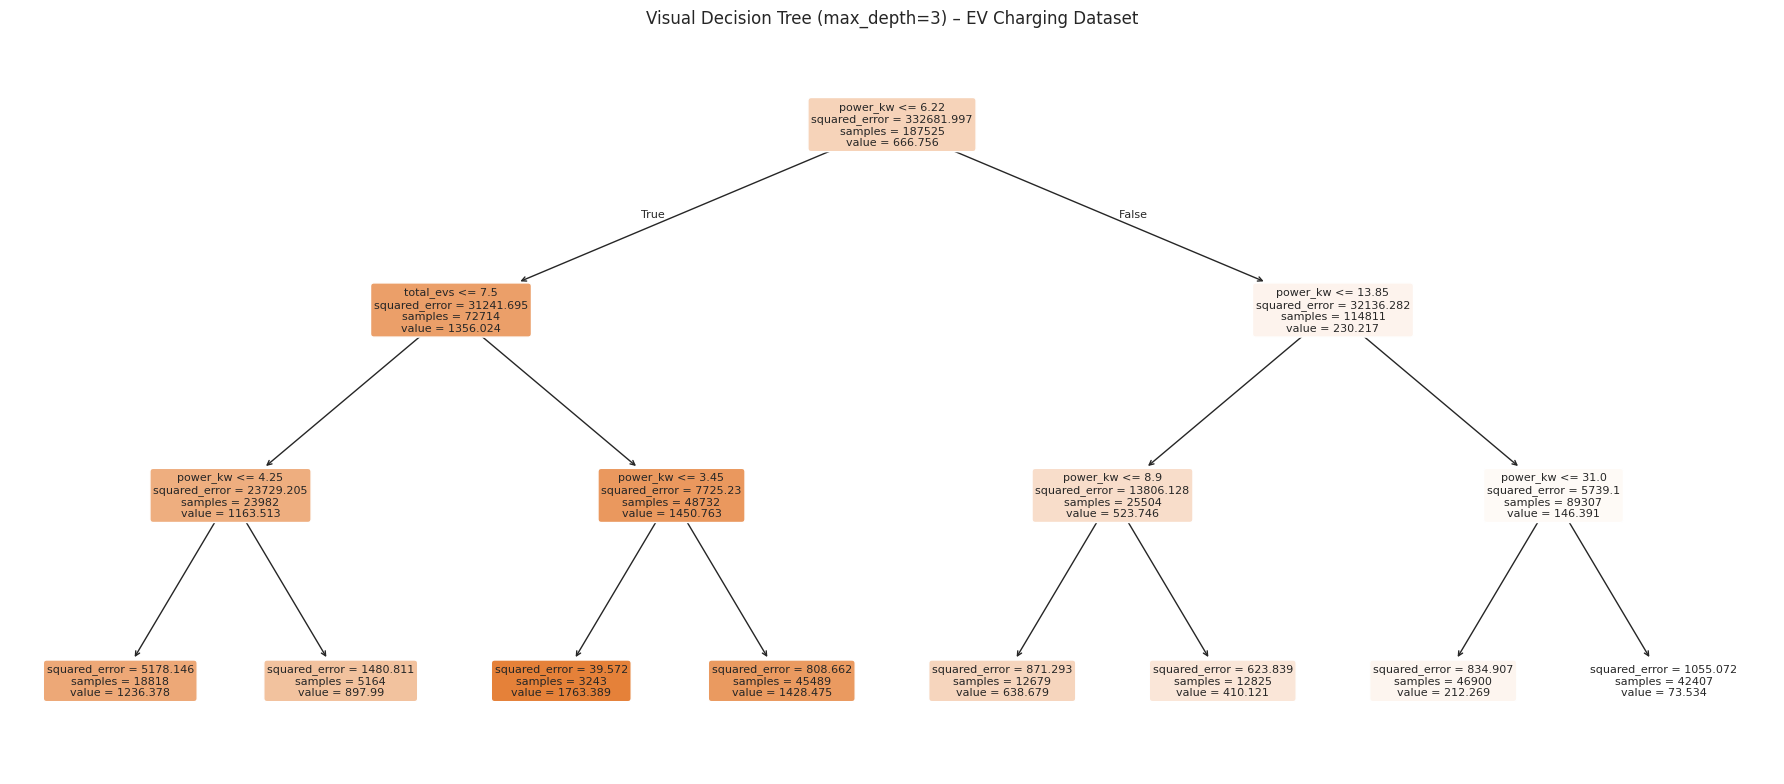

In [56]:
dt = DecisionTreeRegressor(random_state=42)

dt_params = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10]
}

dt_grid = GridSearchCV(
    dt, dt_params,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_

dt_results = evaluate_model(
    "Decision Tree", best_dt,
    X_train, y_train, X_test, y_test
)
results.append(dt_results)

# ---- visual tree with our dataset (small depth) ----
vis_dt = DecisionTreeRegressor(max_depth=3, random_state=42)
vis_dt.fit(X_train, y_train)

plt.figure(figsize=(18, 8))
plot_tree(
    vis_dt,
    feature_names=X_encoded.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Visual Decision Tree (max_depth=3) – EV Charging Dataset")
plt.tight_layout()
plt.show()

In [57]:
rf_train_sample = X_train.sample(frac=0.3, random_state=42)
rf_y_sample = y_train.loc[rf_train_sample.index]
print("Random Forest tuning sample size:", rf_train_sample.shape)

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    rf, rf_params,
    n_iter=6,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_search.fit(rf_train_sample, rf_y_sample)
print("Best RF params:", rf_search.best_params_)

best_rf = RandomForestRegressor(
    **rf_search.best_params_,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)

rf_results = evaluate_model(
    "Random Forest", best_rf,
    X_train, y_train, X_test, y_test
)
results.append(rf_results)


Random Forest tuning sample size: (56258, 5)
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best RF params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Random Forest
-------------
RMSE train: 0.847
RMSE test : 1.252
MAE test  : 0.038
R² test   : 1.000


Gradient Boosting tuning sample size: (56258, 5)
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best GB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

Gradient Boosting
-----------------
RMSE train: 1.530
RMSE test : 1.712
MAE test  : 0.331
R² test   : 1.000


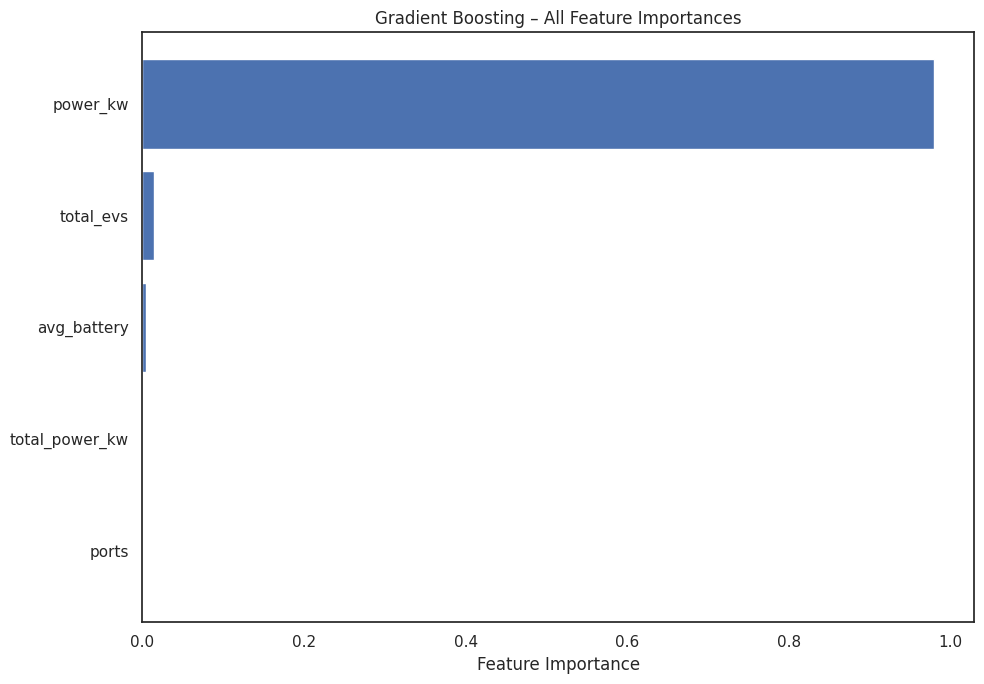

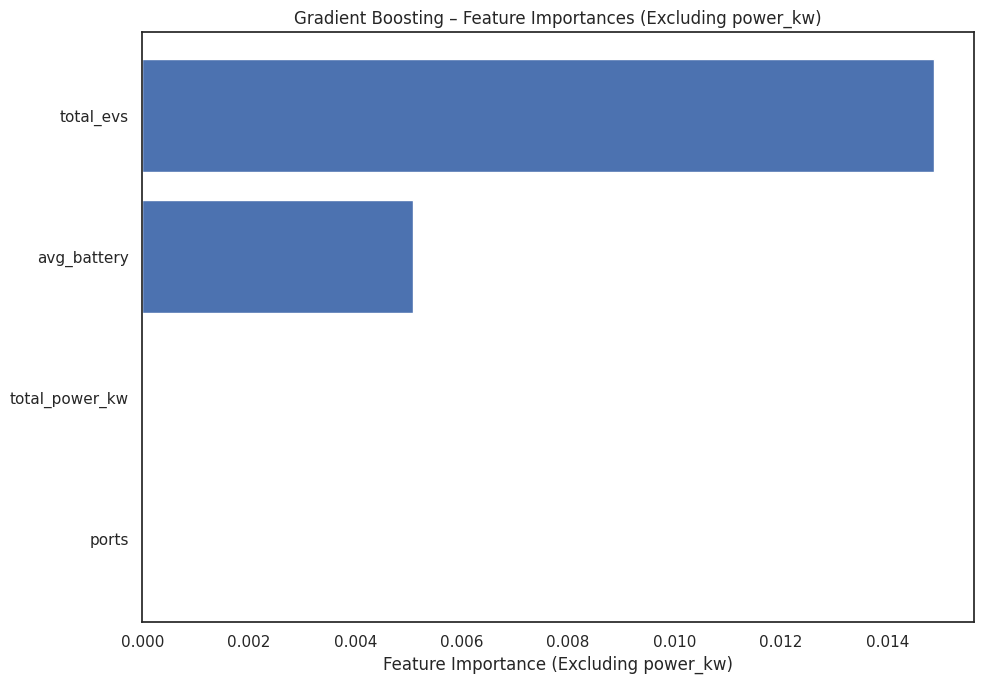

In [58]:
gb_train_sample = X_train.sample(frac=0.3, random_state=42)
gb_y_sample = y_train.loc[gb_train_sample.index]
print("Gradient Boosting tuning sample size:", gb_train_sample.shape)

gbr = GradientBoostingRegressor(random_state=42)

gbr_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.03, 0.1],
    "max_depth": [2, 3]
}

gbr_grid = GridSearchCV(
    gbr, gbr_params,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)
gbr_grid.fit(gb_train_sample, gb_y_sample)
print("Best GB params:", gbr_grid.best_params_)

best_gbr = GradientBoostingRegressor(
    **gbr_grid.best_params_,
    random_state=42
)
best_gbr.fit(X_train, y_train)

gbr_results = evaluate_model(
    "Gradient Boosting", best_gbr,
    X_train, y_train, X_test, y_test
)
results.append(gbr_results)

# Gradient Boosting Feature Importances
importances_gbr = best_gbr.feature_importances_
feature_names_gbr = X_encoded.columns

# Sort features by importance
sorted_indices = np.argsort(importances_gbr)[::-1]
sorted_importances = importances_gbr[sorted_indices]
sorted_names = feature_names_gbr[sorted_indices]

# Plot all feature importances
plt.figure(figsize=(10, 7))
plt.barh(range(len(sorted_importances)), sorted_importances[::-1])
plt.yticks(range(len(sorted_importances)), sorted_names[::-1])
plt.xlabel("Feature Importance")
plt.title("Gradient Boosting – All Feature Importances")
plt.tight_layout()
plt.show()

# Plot feature importances excluding 'power_kw' for better visibility of other features
try:
    # Create a mask to exclude 'power_kw'
    mask = np.array([name != 'power_kw' for name in feature_names_gbr])

    importances_gbr_no_power_kw = importances_gbr[mask]
    feature_names_gbr_no_power_kw = feature_names_gbr[mask]

    # Sort the remaining features
    sorted_indices_no_power_kw = np.argsort(importances_gbr_no_power_kw)[::-1]
    sorted_importances_no_power_kw = importances_gbr_no_power_kw[sorted_indices_no_power_kw]
    sorted_names_no_power_kw = feature_names_gbr_no_power_kw[sorted_indices_no_power_kw]

    if len(sorted_importances_no_power_kw) > 0:
        plt.figure(figsize=(10, 7))
        plt.barh(range(len(sorted_importances_no_power_kw)), sorted_importances_no_power_kw[::-1])
        plt.yticks(range(len(sorted_importances_no_power_kw)), sorted_names_no_power_kw[::-1])
        plt.xlabel("Feature Importance (Excluding power_kw)")
        plt.title("Gradient Boosting – Feature Importances (Excluding power_kw)")
        plt.tight_layout()
        plt.show()
    else:
        print("No features remaining after excluding 'power_kw' for plotting.")

except ValueError:
    print("'power_kw' not found in feature names, skipping exclusion plot.")

In [59]:
try:
    from xgboost import XGBRegressor

    xgb = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    xgb.fit(X_train, y_train)

    xgb_results = evaluate_model(
        "XGBoost", xgb,
        X_train, y_train, X_test, y_test
    )
    results.append(xgb_results)

except ImportError:
    xgb = None
    print("XGBoost not installed. Skipping.")


XGBoost
-------
RMSE train: 5.685
RMSE test : 5.724
MAE test  : 1.433
R² test   : 1.000


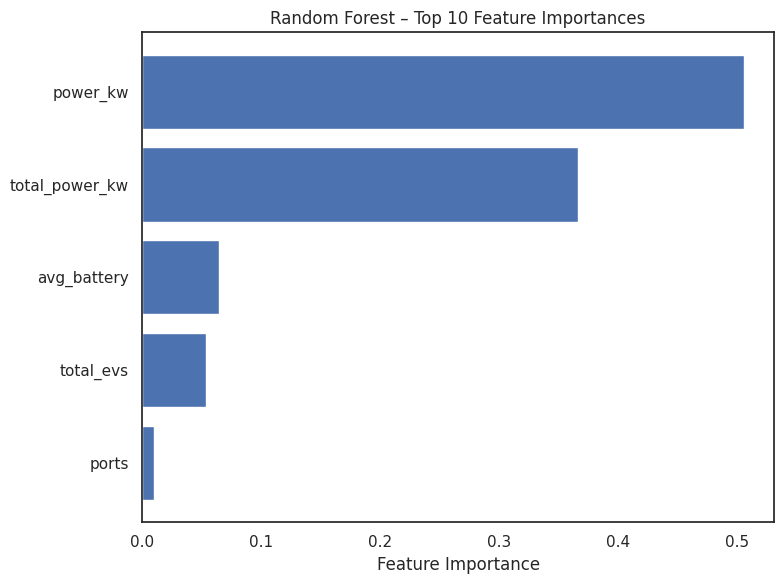

In [60]:
#Random Foresr Top 10 Features
importances = best_rf.feature_importances_
feature_names = X_encoded.columns

indices = np.argsort(importances)[::-1]
top_n = 10
top_indices = indices[:top_n]
top_importances = importances[top_indices]
top_names = feature_names[top_indices]

plt.figure(figsize=(8, 6))
plt.barh(range(len(top_importances)), top_importances[::-1])
plt.yticks(range(len(top_importances)), top_names[::-1])
plt.xlabel("Feature Importance")
plt.title("Random Forest – Top 10 Feature Importances")
plt.tight_layout()
plt.show()

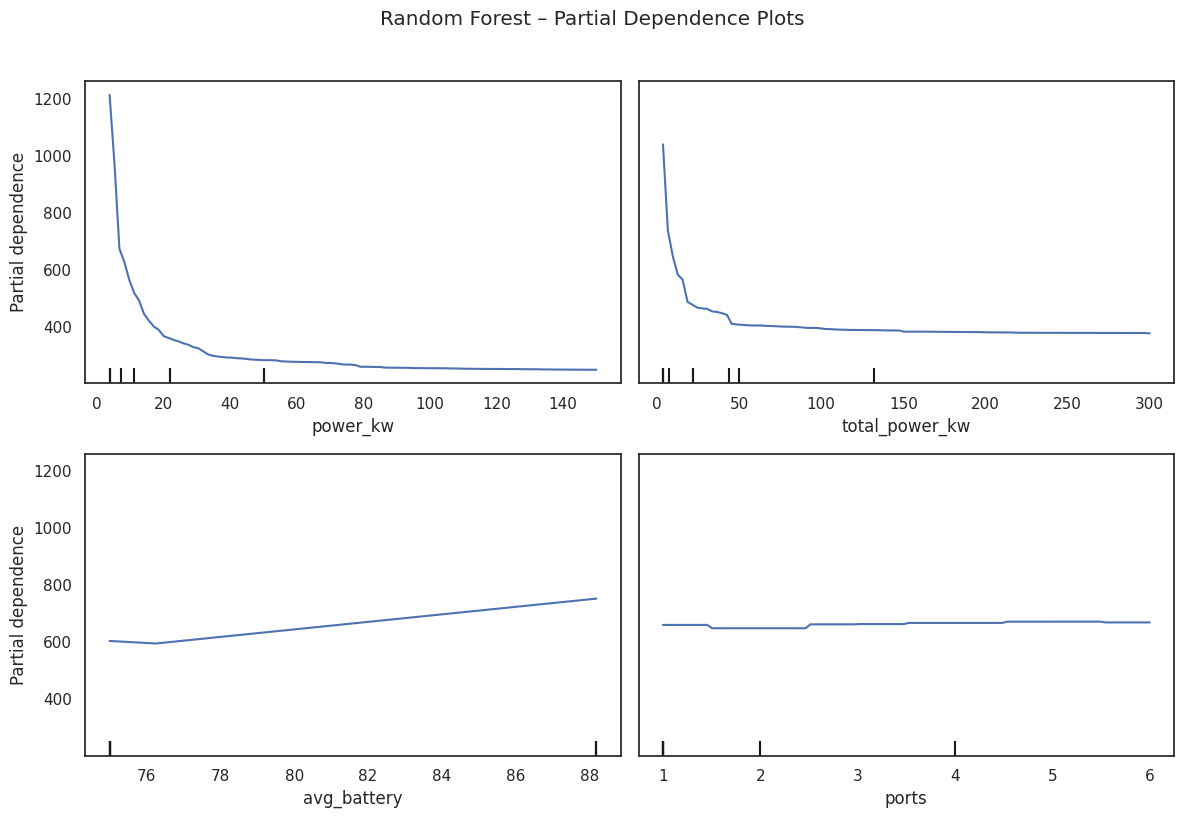

In [61]:
features_for_pdp = [
    "power_kw",
    "total_power_kw",
    "avg_battery",
    "ports"
]

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

PartialDependenceDisplay.from_estimator(
    best_rf,
    X_encoded,
    features_for_pdp,
    kind="average",
    ax=ax
)

plt.suptitle("Random Forest – Partial Dependence Plots", y=1.02)
plt.tight_layout()
plt.show()


In [62]:
results_df = pd.DataFrame(results)
results_df.to_csv("tree_models_performance.csv", index=False)

print("\nSaved performance table → tree_models_performance.csv")
display(results_df)


Saved performance table → tree_models_performance.csv


,model,RMSE_train,RMSE_test,MAE_test,R2_test
0,Decision Tree,0.197666,0.407515,0.008039,1.000000
1,Random Forest,0.846706,1.252109,0.037634,0.999995
2,Gradient Boosting,1.529543,1.712375,0.330595,0.999991
3,XGBoost,5.684580,5.723856,1.432770,0.999901


In [63]:
results_df_new = pd.DataFrame(results)
# Drop duplicate model entries, keeping the last (most recent) run for each model name
results_df_new = results_df_new.drop_duplicates(subset=['model'], keep='last')
print("Model Performance Comparison (with and without new features, cleaned):")
display(results_df_new)

Model Performance Comparison (with and without new features, cleaned):


,model,RMSE_train,RMSE_test,MAE_test,R2_test
0,Decision Tree,0.197666,0.407515,0.008039,1.000000
1,Random Forest,0.846706,1.252109,0.037634,0.999995
2,Gradient Boosting,1.529543,1.712375,0.330595,0.999991
3,XGBoost,5.684580,5.723856,1.432770,0.999901


In [64]:
y_pred_rf = best_rf.predict(X_test)
print("Random Forest predictions generated.")

Random Forest predictions generated.


In [65]:
y_pred_rf_series = pd.Series(y_pred_rf, index=y_test.index)
sample_indices = y_test.sample(n=10, random_state=42).index
comparison_df = pd.DataFrame({
    'Actual': y_test.loc[sample_indices],
    'Predicted': y_pred_rf_series.loc[sample_indices]
})
print("Sample of Actual vs. Predicted Charging Times:")
display(comparison_df)

Sample of Actual vs. Predicted Charging Times:


,Actual,Predicted
198446,18.000000,18.000000
87598,90.000000,90.000000
164824,30.000000,30.000000
24760,330.681818,330.681818
26772,608.108108,608.108108
73813,250.000000,250.000000
111866,29.393939,29.193255
87241,90.000000,90.000000
56501,1429.975430,1429.975430
104492,642.857143,642.857143


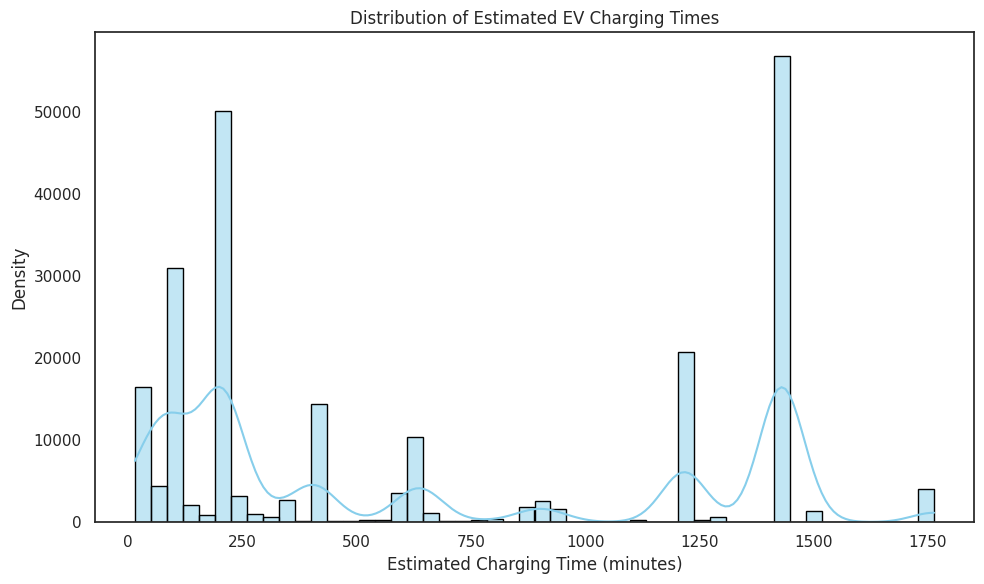

In [66]:
plt.figure(figsize=(10, 6))
sns.histplot(df["charge_time_est_mins"], bins=50, kde=True, color='skyblue', edgecolor='black')
plt.xlabel("Estimated Charging Time (minutes)")
plt.ylabel("Density")
plt.title("Distribution of Estimated EV Charging Times")
plt.tight_layout()
plt.show()